## LSTM for DNA Splice Junction Classification

We want to apply an LSTM to a real biological sequence classification task: identifying splice junction boundaries in primate DNA.

**What is splicing?**
After DNA is transcribed into pre-mRNA, non-coding regions called **introns** are removed and the coding regions (**exons**) are joined together. The precise boundaries where this cut-and-join happens are called **splice junctions**. Your task is to identify them from raw sequences.

**The three classes:**
- **EI**: exon/intron boundary (where an exon ends and an intron begins)
- **IE**: intron/exon boundary (where an intron ends and an exon begins)
- **N**: neither boundary

**Dataset:** [UCI Molecular Biology. Splice-junction Gene Sequences (1991)](https://archive.ics.uci.edu/dataset/69/molecular+biology+splice+junction+gene+sequences)
- 3,190 sequences, each exactly **60 bp** long (positions −30 to +30 relative to the junction)
- human genomic DNA

**Loading Libraries and Subroutines**

Standard libraries for plotting and numerical operations:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Loading LSTM-related Keras libraries:

In [2]:
from keras import optimizers
from keras.layers import LSTM, Dense, Bidirectional, Conv1D, MaxPooling1D
from keras.models import Sequential
from keras.utils import to_categorical

Subroutine for parsing a FASTA file into labelled sequence records:<br>
<br>
FASTA format: each record begins with a `>` header line followed by the sequence.<br>
Here the header encodes the class label: `>EI|name`, `>IE|name`, or `>N|name`.

In [3]:
def parse_fasta(filepath):
    sequences = []
    labels    = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                label = line[1:].split('|')[0]
                sequences.append('')
                labels.append(label)
            elif line:
                sequences[-1] += line.lower()
    return sequences, labels

**1) Loading and Preparing the Data**

1a) Reading the FASTA file:

In [4]:
seqs, labels = parse_fasta('splice_junctions.fasta')

print(f'Total sequences : {len(seqs)}')
print(f'Class counts    : {Counter(labels)}')
print(f'\nExample record  :')
print(f'  seq     = {seqs[0]}')
print(f'  label   = {labels[0]}')

Total sequences : 3190
Class counts    : Counter({'N': 1655, 'IE': 768, 'EI': 767})

Example record  :
  seq     = ccagctgcatcacaggaggccagcgagcaggtctgttccaagggccttcgagccagtctg
  label   = EI


1b) One-hot encoding:

Each nucleotide is encoded as a 5-dimensional binary vector (A, T, C, G, other).
A sequence of length 60 becomes a matrix of shape *(60, 5)*.

The labels are integer-encoded (EI=0, IE=1, N=2) and converted to one-hot vectors.

In [5]:
SEQ_LEN     = 60
N_CLASSES   = 3
NUCLEOTIDES = ['a', 't', 'c', 'g']
NUC_TO_IDX  = {n: i for i, n in enumerate(NUCLEOTIDES)}

def one_hot(seq):
    """One-hot encode one sequence. Returns shape (60, 5).
    Channels 0-3: A, T, C, G.  Channel 4: ambiguous/other.
    """
    enc = np.zeros((SEQ_LEN, 5), dtype=np.float32)
    for i, nuc in enumerate(seq[:SEQ_LEN]):
        enc[i, NUC_TO_IDX.get(nuc, 4)] = 1.0
    return enc

X = np.stack([one_hot(seq) for seq in seqs])              # (3190, 60, 5)

le    = LabelEncoder()
y_int = le.fit_transform(labels)           # integer labels (3190,)
y_cat = to_categorical(y_int, num_classes=N_CLASSES)            # one-hot (3190, 3)

class_names = list(le.classes_)
print(f'X shape      : {X.shape}')
print(f'y_cat shape  : {y_cat.shape}')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X shape      : (3190, 60, 5)
y_cat shape  : (3190, 3)
Class mapping: {np.str_('EI'): np.int64(0), np.str_('IE'): np.int64(1), np.str_('N'): np.int64(2)}


1c) Splitting into training and test sets:

In [6]:
TrainX, TestX, TrainY, TestY = train_test_split(
    X, y_cat, test_size=0.2, random_state=47, stratify=y_int
)

print(f'Train : {TrainX.shape[0]} sequences')
print(f'Test  : {TestX.shape[0]} sequences')

Train : 2552 sequences
Test  : 638 sequences


**2) Vanilla LSTM**

Two things change compared to binary classification:
- The output layer uses `softmax` (not `sigmoid`), producing a probability for each of the 3 classes
- The loss function is `categorical_crossentropy` (not `binary_crossentropy`)

2a) Generating the model:

In [7]:
n_neurons  = 64
n_features = 5   # one-hot channels: A, T, C, G, other
batch_size = 64

model = Sequential()
model.add(LSTM(n_neurons, input_shape=(SEQ_LEN, n_features), activation='tanh'))
model.add(Dense(N_CLASSES, activation='softmax'))

opt = optimizers.Adam()
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

model.summary()

C:\Users\MMH_user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,115 (70.76 KB)

 Trainable params: 18,115 (70.76 KB)

 Non-trainable params: 0 (0.00 B)

<br>
2b) Fitting the model:

In [8]:
n_epochs = 30
out = model.fit(TrainX, TrainY,
                epochs=n_epochs, batch_size=batch_size,
                validation_split=0.2, verbose=2, shuffle=True)

Epoch 1/30
32/32 - 4s - 118ms/step - accuracy: 0.5061 - loss: 1.0404 - val_accuracy: 0.5323 - val_loss: 1.0078
Epoch 2/30
32/32 - 1s - 31ms/step - accuracy: 0.5272 - loss: 0.9975 - val_accuracy: 0.5538 - val_loss: 0.9794
Epoch 3/30
32/32 - 1s - 32ms/step - accuracy: 0.5336 - loss: 0.9588 - val_accuracy: 0.5773 - val_loss: 0.8877
Epoch 4/30
32/32 - 1s - 42ms/step - accuracy: 0.5840 - loss: 0.8676 - val_accuracy: 0.6164 - val_loss: 0.8381
Epoch 5/30
32/32 - 2s - 47ms/step - accuracy: 0.6335 - loss: 0.7970 - val_accuracy: 0.6262 - val_loss: 0.7732
Epoch 6/30
32/32 - 1s - 32ms/step - accuracy: 0.6516 - loss: 0.7660 - val_accuracy: 0.6360 - val_loss: 0.7654
Epoch 7/30
32/32 - 1s - 25ms/step - accuracy: 0.6654 - loss: 0.7291 - val_accuracy: 0.6712 - val_loss: 0.7311
Epoch 8/30
32/32 - 1s - 33ms/step - accuracy: 0.6820 - loss: 0.7113 - val_accuracy: 0.6908 - val_loss: 0.6978
Epoch 9/30
32/32 - 1s - 32ms/step - accuracy: 0.6884 - loss: 0.6913 - val_accuracy: 0.7162 - val_loss: 0.6576
Epoch 10/

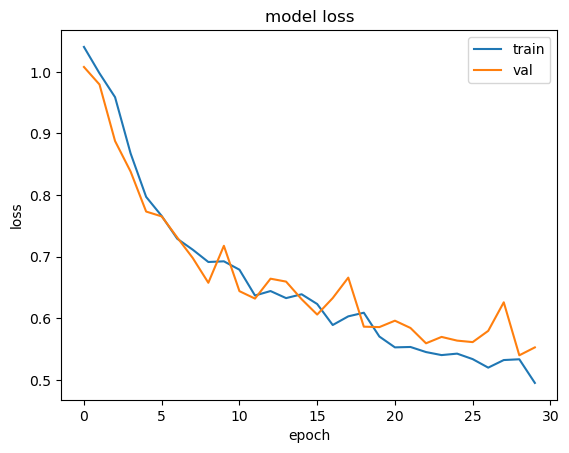

In [9]:
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

<br>
2c) Evaluating on the test set:

In [10]:
test_loss, test_acc = model.evaluate(TestX, TestY, verbose=0)
print(f'Test accuracy : {test_acc:.3f}')

Test accuracy : 0.796


---

**3) Improving the Model**

Your goal is to modify the architecture and improve on the vanilla LSTM's test accuracy.

**Some directions to explore:**
- **Bidirectional LSTM**
- **Stacked LSTM**
- **CNN + LSTM**
- **Regularization**
- **Hyperparameter tuning**

3a) Generating the model:

In [ ]:
model = Sequential()
# --- modify the architecture below ---
model.add(LSTM(n_neurons, input_shape=(SEQ_LEN, n_features), activation='tanh'))
model.add(Dense(N_CLASSES, activation='softmax'))

opt = optimizers.Adam()
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

model.summary()

<br>
3b) Fitting the model:

In [ ]:
out = model.fit(TrainX, TrainY,
                epochs=n_epochs, batch_size=batch_size,
                validation_split=0.2, verbose=2, shuffle=True)

In [ ]:
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

<br>
3c) Evaluating on the test set:

In [ ]:
test_loss, test_acc = model.evaluate(TestX, TestY, verbose=0)
print(f'Test accuracy : {test_acc:.3f}')